# EDA Complete - Heart Disease Dataset (UCI)
### Projet 2 - Analyse exploratoire sur donnees reelles Kaggle
> 1025 patients | 14 variables | Objectif : identifier les facteurs de risque cardiaque

**Variables du dataset :**
- `age` : age du patient
- `sex` : sexe (1=Homme, 0=Femme)
- `cp` : type de douleur thoracique (0-3)
- `trestbps` : tension au repos (mmHg)
- `chol` : cholesterol (mg/dl)
- `fbs` : glycemie a jeun > 120 mg/dl (1=Oui, 0=Non)
- `restecg` : resultats ECG au repos (0-2)
- `thalach` : frequence cardiaque max
- `exang` : angine induite par exercice (1=Oui, 0=Non)
- `oldpeak` : depression ST induite par exercice
- `slope` : pente du segment ST
- `ca` : nb vaisseaux colores par fluoroscopie (0-4)
- `thal` : thalassemie (0-3)
- `target` : maladie cardiaque (1=Oui, 0=Non)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

# Charger le dataset
df = pd.read_csv('/home/joachin/formation_data/heart.csv')

print(f'Dataset charge : {df.shape[0]} patients x {df.shape[1]} variables')
print()
print(df.head(8).to_string())

Dataset charge : 1025 patients x 14 variables

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0   52    1   0       125   212    0        1      168      0      1.0      2   2     3       0
1   53    1   0       140   203    1        0      155      1      3.1      0   0     3       0
2   70    1   0       145   174    0        1      125      1      2.6      0   0     3       0
3   61    1   0       148   203    0        1      161      0      0.0      2   1     3       0
4   62    0   0       138   294    1        1      106      0      1.9      1   3     2       0
5   58    0   0       100   248    0        0      122      0      1.0      1   0     2       1
6   58    1   0       114   318    0        2      140      0      4.4      0   3     1       0
7   55    1   0       160   289    0        0      145      1      0.8      1   1     3       0


---
## ETAPE 1 - Premier regard sur les donnees

In [3]:
print('TYPES ET MANQUANTS')
print('-'*40)
info = pd.DataFrame({
    'Type'     : df.dtypes,
    'Manquants': df.isnull().sum(),
    'Uniques'  : df.nunique(),
    'Min'      : df.min(),
    'Max'      : df.max()
})
print(info.to_string())
print()
print(f'Total manquants : {df.isnull().sum().sum()} => Dataset propre !')

TYPES ET MANQUANTS
----------------------------------------
             Type  Manquants  Uniques    Min    Max
age         int64          0       41   29.0   77.0
sex         int64          0        2    0.0    1.0
cp          int64          0        4    0.0    3.0
trestbps    int64          0       49   94.0  200.0
chol        int64          0      152  126.0  564.0
fbs         int64          0        2    0.0    1.0
restecg     int64          0        3    0.0    2.0
thalach     int64          0       91   71.0  202.0
exang       int64          0        2    0.0    1.0
oldpeak   float64          0       40    0.0    6.2
slope       int64          0        3    0.0    2.0
ca          int64          0        5    0.0    4.0
thal        int64          0        4    0.0    3.0
target      int64          0        2    0.0    1.0

Total manquants : 0 => Dataset propre !


In [4]:
print('STATISTIQUES DESCRIPTIVES (Dodge - Moyenne, Mediane, Ecart type)')
print('-'*60)
print(df.describe().round(2).to_string())
print()
print('VARIABLE CIBLE - target')
print(df['target'].value_counts().to_string())
print(f'Prevalence maladie cardiaque : {df["target"].mean()*100:.1f}%')

STATISTIQUES DESCRIPTIVES (Dodge - Moyenne, Mediane, Ecart type)
------------------------------------------------------------
           age      sex       cp  trestbps     chol      fbs  restecg  thalach    exang  oldpeak    slope       ca     thal   target
count  1025.00  1025.00  1025.00   1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00  1025.00
mean     54.43     0.70     0.94    131.61   246.00     0.15     0.53   149.11     0.34     1.07     1.39     0.75     2.32     0.51
std       9.07     0.46     1.03     17.52    51.59     0.36     0.53    23.01     0.47     1.18     0.62     1.03     0.62     0.50
min      29.00     0.00     0.00     94.00   126.00     0.00     0.00    71.00     0.00     0.00     0.00     0.00     0.00     0.00
25%      48.00     0.00     0.00    120.00   211.00     0.00     0.00   132.00     0.00     0.00     1.00     0.00     2.00     0.00
50%      56.00     1.00     1.00    130.00   240.00     0.00     1.00   152.

---
## ETAPE 2 - Distribution des variables continues
> Dodge : Distribution, Moyenne, Mediane, Ecart type, Box plot

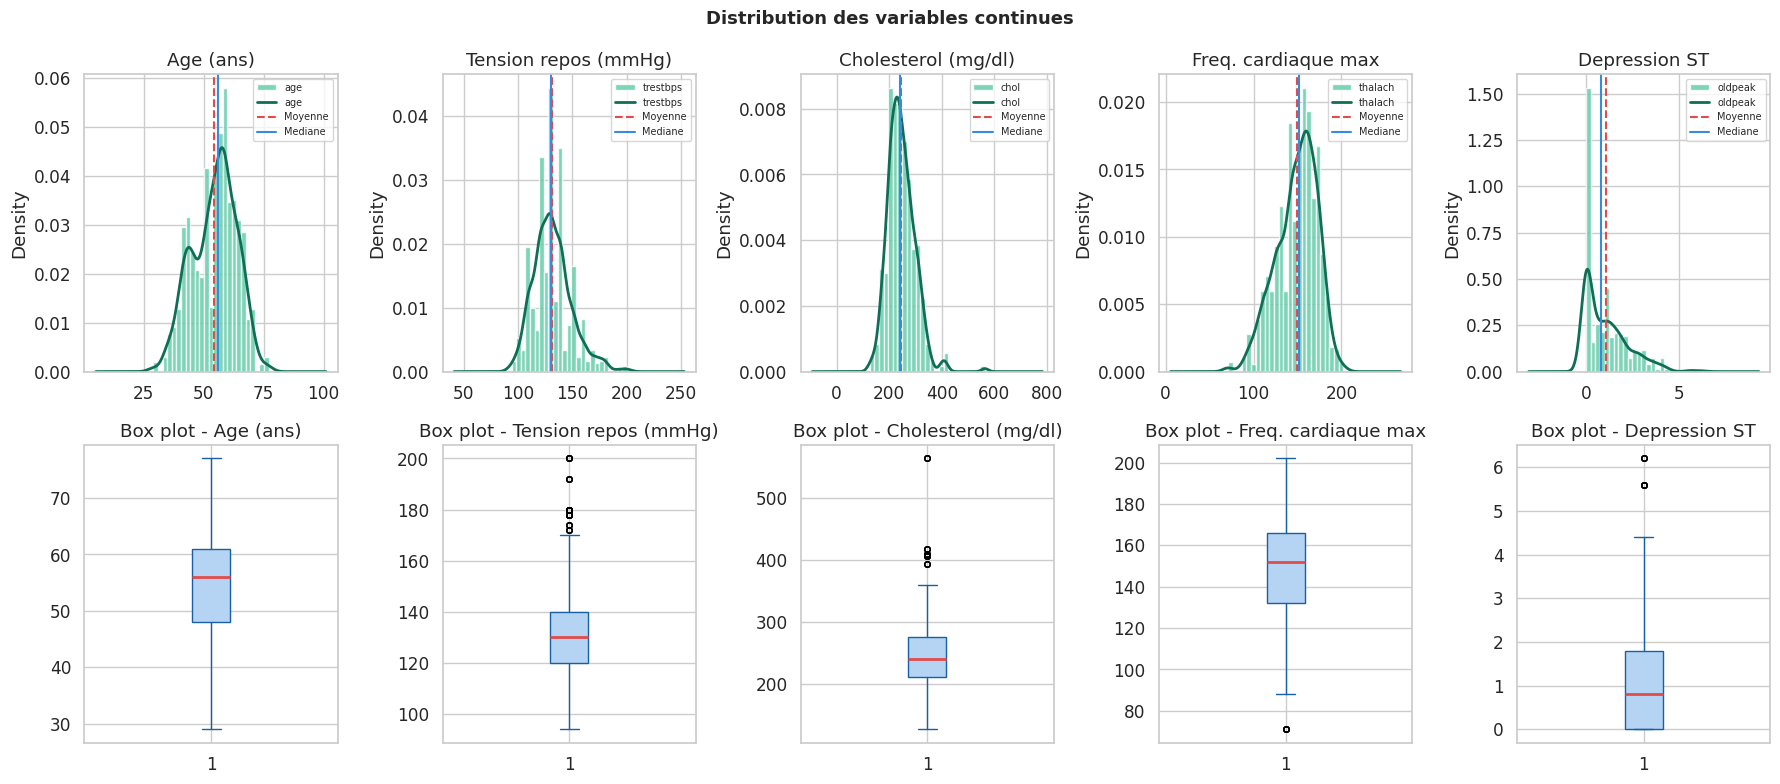

RESUME STATISTIQUE
-------------------------------------------------------
  Age (ans)                 moy=54.4  med=56.0  std=9.1  skew=-0.25 (Symetrique)
  Tension repos (mmHg)      moy=131.6  med=130.0  std=17.5  skew=0.74 (Asymetrie droite)
  Cholesterol (mg/dl)       moy=246.0  med=240.0  std=51.6  skew=1.07 (Asymetrie droite)
  Freq. cardiaque max       moy=149.1  med=152.0  std=23.0  skew=-0.51 (Asymetrie gauche)
  Depression ST             moy=1.1  med=0.8  std=1.2  skew=1.21 (Asymetrie droite)


In [5]:
vars_continues = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
labels = [
    'Age (ans)',
    'Tension repos (mmHg)',
    'Cholesterol (mg/dl)',
    'Freq. cardiaque max',
    'Depression ST'
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, (var, lbl) in enumerate(zip(vars_continues, labels)):
    # Histogramme + KDE
    ax = axes[0][i]
    df[var].plot(kind='hist', bins=25, density=True, color='#5DCAA5',
                 edgecolor='white', alpha=0.8, ax=ax)
    df[var].plot(kind='kde', color='#0F6E56', lw=2, ax=ax)
    ax.axvline(df[var].mean(),   color='#E24B4A', ls='--', lw=1.5, label='Moyenne')
    ax.axvline(df[var].median(), color='#378ADD', ls='-',  lw=1.5, label='Mediane')
    ax.set_title(lbl)
    ax.legend(fontsize=7)

    # Box plot
    ax2 = axes[1][i]
    ax2.boxplot(df[var].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                medianprops=dict(color='#E24B4A', lw=2),
                whiskerprops=dict(color='#185FA5'),
                capprops=dict(color='#185FA5'),
                flierprops=dict(marker='o', color='#E24B4A', ms=4))
    ax2.set_title(f'Box plot - {lbl}')

plt.suptitle('Distribution des variables continues', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('RESUME STATISTIQUE')
print('-'*55)
for var, lbl in zip(vars_continues, labels):
    s = df[var]
    skew = s.skew()
    forme = 'Asymetrie droite' if skew > 0.5 else 'Asymetrie gauche' if skew < -0.5 else 'Symetrique'
    print(f'  {lbl:<25} moy={s.mean():.1f}  med={s.median():.1f}  std={s.std():.1f}  skew={skew:.2f} ({forme})')

---
## ETAPE 3 - Distribution des variables categorielles
> Dodge : Mode, Diagramme en barres

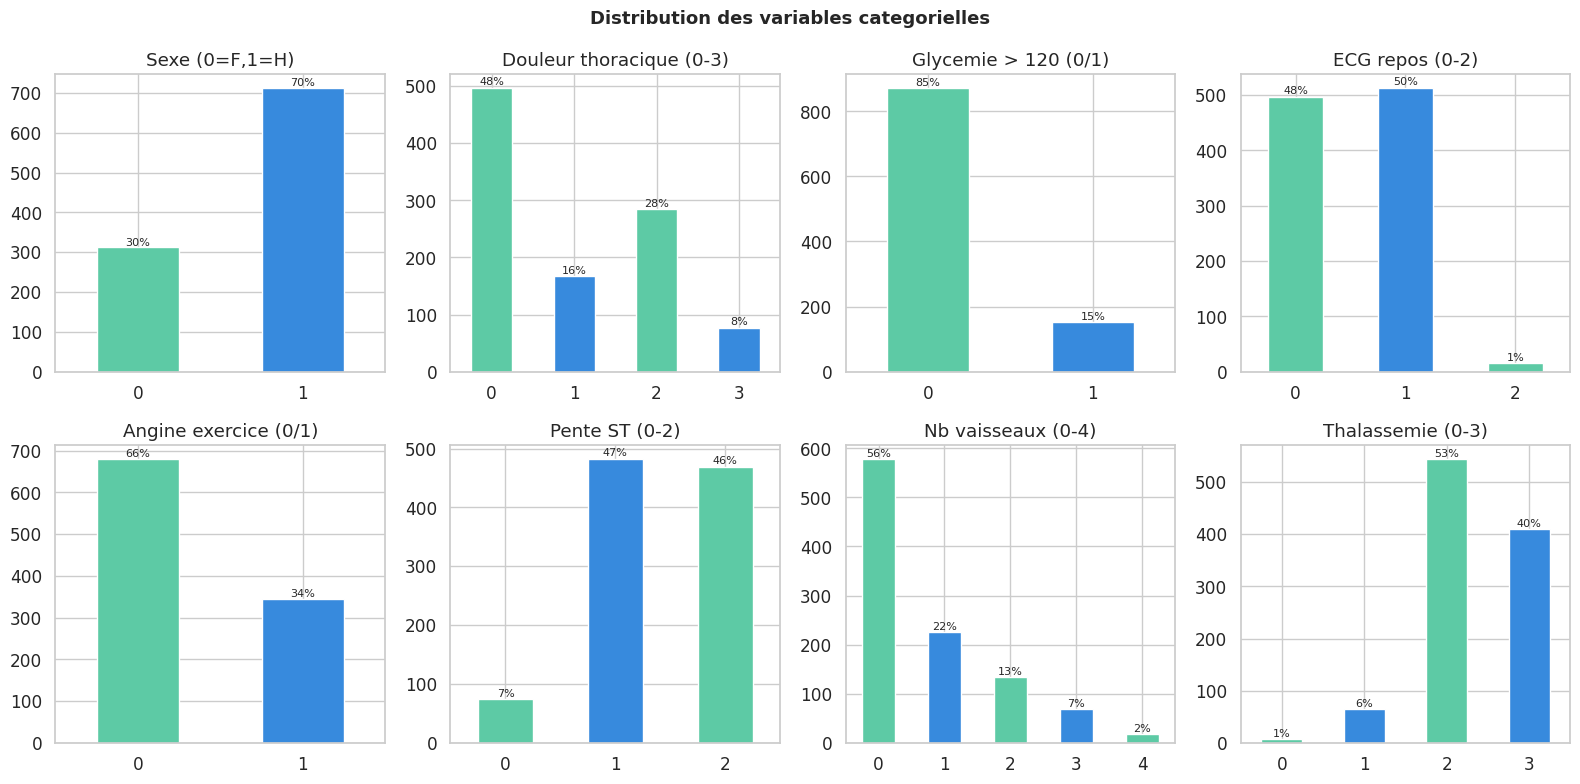

In [6]:
vars_cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
labels_cat = [
    'Sexe (0=F,1=H)',
    'Douleur thoracique (0-3)',
    'Glycemie > 120 (0/1)',
    'ECG repos (0-2)',
    'Angine exercice (0/1)',
    'Pente ST (0-2)',
    'Nb vaisseaux (0-4)',
    'Thalassemie (0-3)'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (var, lbl) in enumerate(zip(vars_cat, labels_cat)):
    ax = axes[i//4][i%4]
    counts = df[var].value_counts().sort_index()
    # Colorer selon target
    colors = ['#5DCAA5' if j%2==0 else '#378ADD' for j in range(len(counts))]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white', rot=0)
    ax.set_title(lbl)
    ax.set_xlabel('')
    # Ajouter pourcentages
    for p in ax.patches:
        pct = p.get_height() / len(df) * 100
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
                f'{pct:.0f}%', ha='center', fontsize=8)

plt.suptitle('Distribution des variables categorielles', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## ETAPE 4 - Analyse bivariee : chaque variable vs target
> Dodge : Cause et effet, Corrélation, Box plot

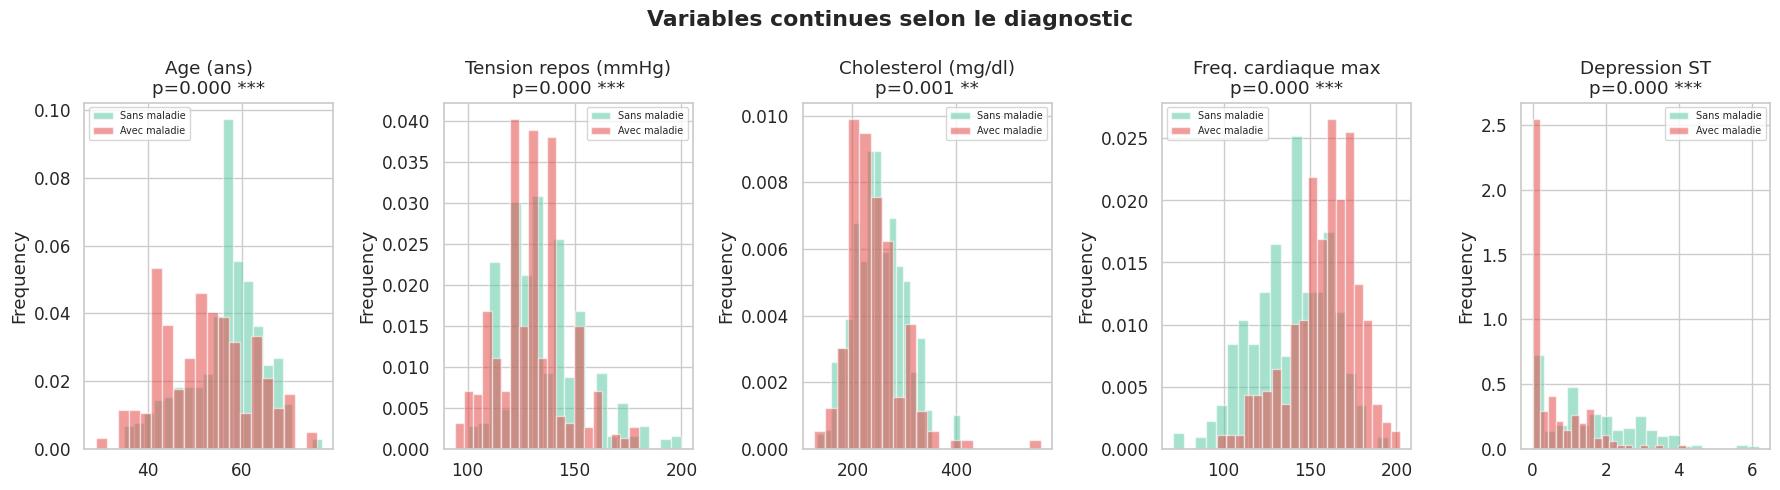

In [7]:
# Variables continues vs target
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, (var, lbl) in enumerate(zip(vars_continues, labels)):
    ax = axes[i]
    for val, col, lbl2 in [(0,'#5DCAA5','Sans maladie'),(1,'#E24B4A','Avec maladie')]:
        df[df['target']==val][var].plot(
            kind='hist', bins=20, alpha=0.55, color=col,
            density=True, ax=ax, label=lbl2, edgecolor='white')
    t, p = stats.ttest_ind(
        df[df['target']==1][var],
        df[df['target']==0][var])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.set_title(f'{lbl}\np={p:.3f} {sig}')
    ax.legend(fontsize=7)

plt.suptitle('Variables continues selon le diagnostic', fontweight='bold')
plt.tight_layout()
plt.show()

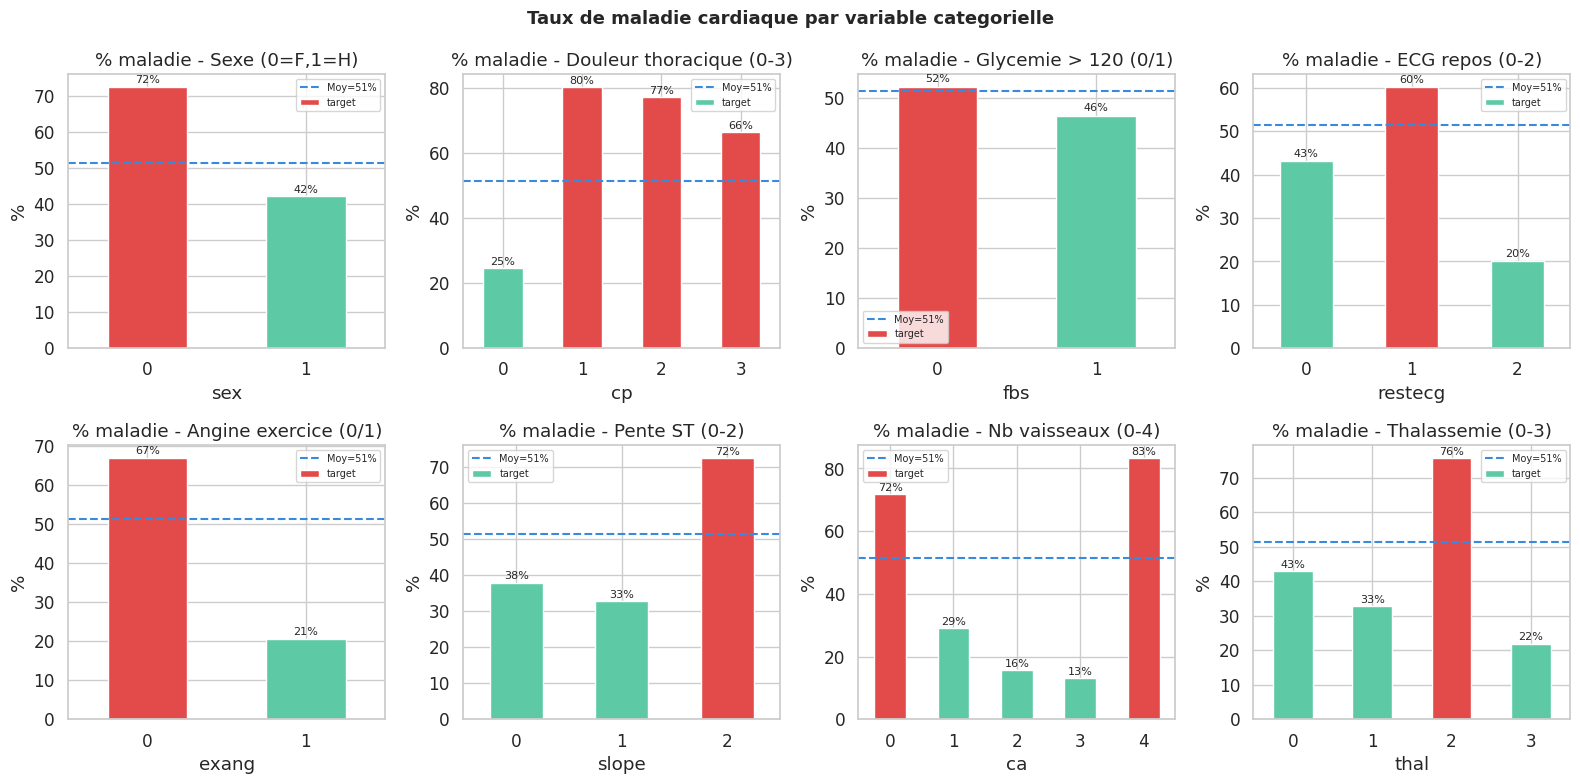

In [8]:
# Variables categorielles vs target - taux de maladie par modalite
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (var, lbl) in enumerate(zip(vars_cat, labels_cat)):
    ax = axes[i//4][i%4]
    taux = df.groupby(var)['target'].mean() * 100
    colors = ['#E24B4A' if v > 50 else '#5DCAA5' for v in taux.values]
    taux.plot(kind='bar', ax=ax, color=colors, edgecolor='white', rot=0)
    ax.axhline(df['target'].mean()*100, color='#378ADD',
               ls='--', lw=1.5, label=f'Moy={df["target"].mean()*100:.0f}%')
    ax.set_title(f'% maladie - {lbl}')
    ax.set_ylabel('%')
    ax.legend(fontsize=7)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1,
                f'{p.get_height():.0f}%', ha='center', fontsize=8)

plt.suptitle('Taux de maladie cardiaque par variable categorielle',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## ETAPE 5 - Matrice de correlation
> Dodge : Coefficient de Pearson, Corrélation de Spearman

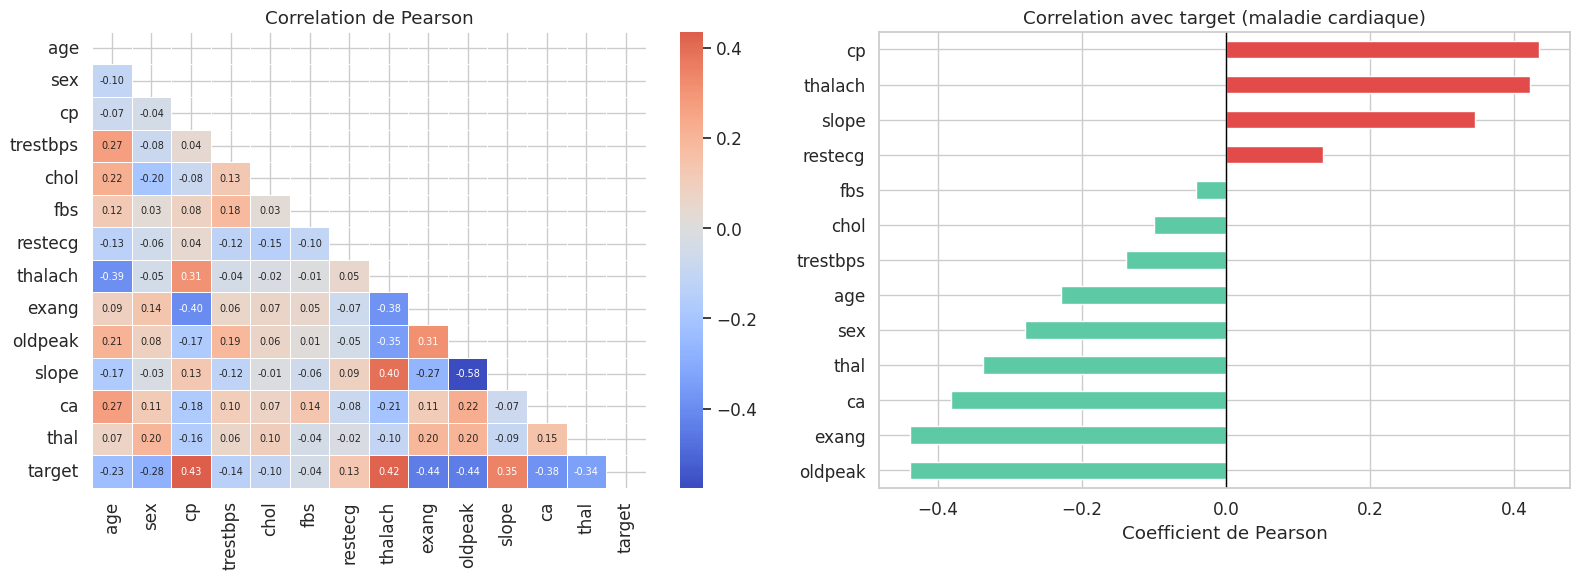

TOP CORRELATIONS AVEC TARGET :
---------------------------------------------
  oldpeak      r= -0.438  Facteur PROTECTEUR
  exang        r= -0.438  Facteur PROTECTEUR
  cp           r=  0.435  Facteur de RISQUE
  thalach      r=  0.423  Facteur de RISQUE
  ca           r= -0.382  Facteur PROTECTEUR
  slope        r=  0.346  Facteur de RISQUE
  thal         r= -0.338  Facteur PROTECTEUR
  sex          r= -0.280  Facteur PROTECTEUR
  age          r= -0.229  Facteur PROTECTEUR
  trestbps     r= -0.139  Facteur PROTECTEUR
  restecg      r=  0.134  Facteur de RISQUE
  chol         r= -0.100  Facteur PROTECTEUR
  fbs          r= -0.041  Facteur PROTECTEUR


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson
corr_p = df.corr(method='pearson')
mask = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0],
            linewidths=0.5, annot_kws={'size':7})
axes[0].set_title('Correlation de Pearson')

# Correlation avec target uniquement (triee)
corr_target = df.corr()['target'].drop('target').sort_values()
colors = ['#E24B4A' if v > 0 else '#5DCAA5' for v in corr_target.values]
corr_target.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Correlation avec target (maladie cardiaque)')
axes[1].set_xlabel('Coefficient de Pearson')

plt.tight_layout()
plt.show()

print('TOP CORRELATIONS AVEC TARGET :')
print('-'*45)
for var, val in corr_target.abs().sort_values(ascending=False).items():
    sens = 'Facteur de RISQUE' if corr_target[var] > 0 else 'Facteur PROTECTEUR'
    print(f'  {var:<12} r={corr_target[var]:>7.3f}  {sens}')

---
## ETAPE 6 - Tests statistiques
> Dodge : Test t, Chi2, Intervalle de confiance

In [10]:
print('TESTS T - Variables continues vs target')
print('='*60)
malade     = df[df['target']==1]
non_malade = df[df['target']==0]

for var, lbl in zip(vars_continues, labels):
    m1 = malade[var].mean()
    m0 = non_malade[var].mean()
    t, p = stats.ttest_ind(malade[var], non_malade[var])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'  {lbl:<25} Malade={m1:.1f}  Sain={m0:.1f}  p={p:.4f} {sig}')

print()
print('TESTS CHI2 - Variables categorielles vs target')
print('='*60)
for var, lbl in zip(vars_cat, labels_cat):
    table = pd.crosstab(df[var], df['target'])
    chi2, p, ddl, _ = stats.chi2_contingency(table)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'  {lbl:<30} chi2={chi2:.1f}  p={p:.4f} {sig}')

TESTS T - Variables continues vs target
  Age (ans)                 Malade=52.4  Sain=56.6  p=0.0000 ***
  Tension repos (mmHg)      Malade=129.2  Sain=134.1  p=0.0000 ***
  Cholesterol (mg/dl)       Malade=241.0  Sain=251.3  p=0.0014 **
  Freq. cardiaque max       Malade=158.6  Sain=139.1  p=0.0000 ***
  Depression ST             Malade=0.6  Sain=1.6  p=0.0000 ***

TESTS CHI2 - Variables categorielles vs target
  Sexe (0=F,1=H)                 chi2=78.9  p=0.0000 ***
  Douleur thoracique (0-3)       chi2=281.0  p=0.0000 ***
  Glycemie > 120 (0/1)           chi2=1.5  p=0.2186 ns
  ECG repos (0-2)                chi2=35.8  p=0.0000 ***
  Angine exercice (0/1)          chi2=194.8  p=0.0000 ***
  Pente ST (0-2)                 chi2=155.9  p=0.0000 ***
  Nb vaisseaux (0-4)             chi2=257.3  p=0.0000 ***
  Thalassemie (0-3)              chi2=280.3  p=0.0000 ***


---
## ETAPE 7 - Pairplot des variables les plus importantes

Top 4 variables : ['oldpeak', 'exang', 'cp', 'thalach']


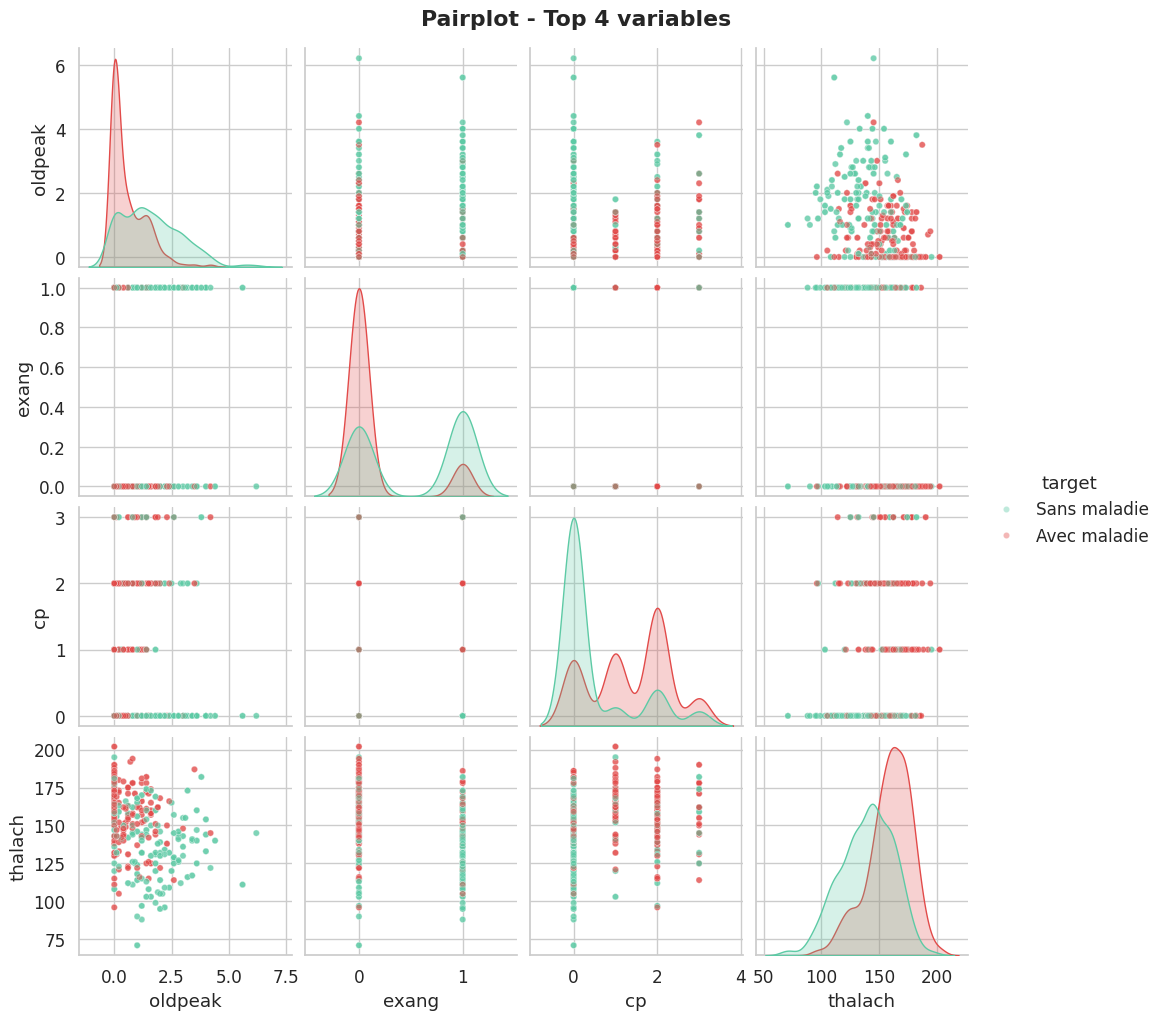

In [11]:
# Top 4 variables les plus correlees avec target
top_vars = corr_target.abs().sort_values(ascending=False).head(4).index.tolist()
print(f'Top 4 variables : {top_vars}')

df_plot = df[top_vars + ['target']].copy()
df_plot['target'] = df_plot['target'].map({0:'Sans maladie', 1:'Avec maladie'})

g = sns.pairplot(df_plot, hue='target',
                 palette={'Sans maladie':'#5DCAA5','Avec maladie':'#E24B4A'},
                 plot_kws={'alpha':0.4, 's':20},
                 diag_kind='kde')
g.fig.suptitle('Pairplot - Top 4 variables', y=1.02, fontweight='bold')
plt.show()

---
## ETAPE 8 - Dashboard EDA final

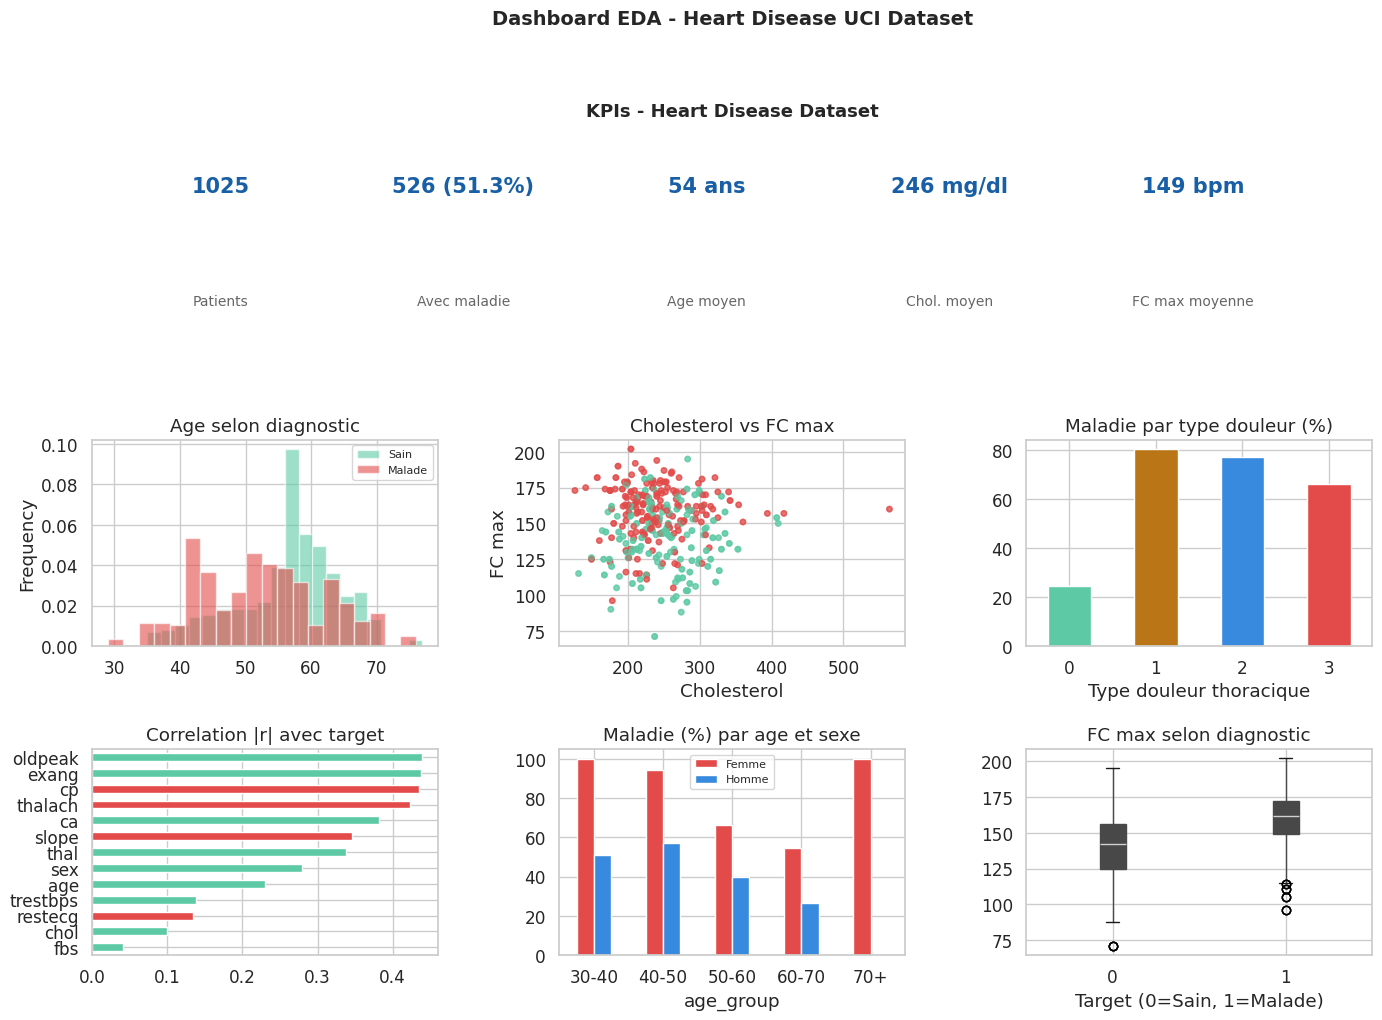

Dashboard sauvegarde : dashboard_heart_eda.png


In [12]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# KPIs
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
kpis = [
    ('Patients',         f'{len(df)}'),
    ('Avec maladie',     f'{df["target"].sum()} ({df["target"].mean()*100:.1f}%)'),
    ('Age moyen',        f'{df["age"].mean():.0f} ans'),
    ('Chol. moyen',      f'{df["chol"].mean():.0f} mg/dl'),
    ('FC max moyenne',   f'{df["thalach"].mean():.0f} bpm'),
]
for i, (label, valeur) in enumerate(kpis):
    x = 0.1 + i * 0.19
    ax_kpi.text(x, 0.7, valeur, transform=ax_kpi.transAxes,
                fontsize=15, fontweight='bold', ha='center', color='#185FA5')
    ax_kpi.text(x, 0.15, label, transform=ax_kpi.transAxes,
                fontsize=10, ha='center', color='#666')
ax_kpi.set_title('KPIs - Heart Disease Dataset', fontsize=13,
                  fontweight='bold', pad=10)

# 1. Distribution age
ax1 = fig.add_subplot(gs[1, 0])
for val, col, lbl in [(0,'#5DCAA5','Sain'),(1,'#E24B4A','Malade')]:
    df[df['target']==val]['age'].plot(
        kind='hist', bins=20, alpha=0.6, color=col,
        density=True, ax=ax1, label=lbl, edgecolor='white')
ax1.set_title('Age selon diagnostic')
ax1.legend(fontsize=8)

# 2. Cholesterol vs FC max
ax2 = fig.add_subplot(gs[1, 1])
colors = df['target'].map({0:'#5DCAA5', 1:'#E24B4A'})
ax2.scatter(df['chol'], df['thalach'], c=colors, alpha=0.4, s=15)
ax2.set_xlabel('Cholesterol')
ax2.set_ylabel('FC max')
ax2.set_title('Cholesterol vs FC max')

# 3. Taux maladie par type douleur
ax3 = fig.add_subplot(gs[1, 2])
taux_cp = df.groupby('cp')['target'].mean() * 100
taux_cp.plot(kind='bar', ax=ax3,
             color=['#5DCAA5','#BA7517','#378ADD','#E24B4A'],
             edgecolor='white', rot=0)
ax3.set_title('Maladie par type douleur (%)')
ax3.set_xlabel('Type douleur thoracique')

# 4. Correlation avec target
ax4 = fig.add_subplot(gs[2, 0])
corr_abs = corr_target.abs().sort_values()
colors4 = ['#E24B4A' if corr_target[v]>0 else '#5DCAA5' for v in corr_abs.index]
corr_abs.plot(kind='barh', ax=ax4, color=colors4, edgecolor='white')
ax4.set_title('Correlation |r| avec target')

# 5. Taux par sexe et age
ax5 = fig.add_subplot(gs[2, 1])
df['age_group'] = pd.cut(df['age'], bins=[29,40,50,60,70,80],
                          labels=['30-40','40-50','50-60','60-70','70+'])
taux_age = df.groupby(['age_group','sex'])['target'].mean().unstack() * 100
taux_age.columns = ['Femme','Homme']
taux_age.plot(kind='bar', ax=ax5, color=['#E24B4A','#378ADD'],
              edgecolor='white', rot=0)
ax5.set_title('Maladie (%) par age et sexe')
ax5.legend(fontsize=8)

# 6. Box plot FC max
ax6 = fig.add_subplot(gs[2, 2])
df.boxplot(column='thalach', by='target', ax=ax6,
           patch_artist=True)
ax6.set_title('FC max selon diagnostic')
ax6.set_xlabel('Target (0=Sain, 1=Malade)')
plt.sca(ax6)
plt.title('FC max selon diagnostic')

fig.suptitle('Dashboard EDA - Heart Disease UCI Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('dashboard_heart_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard sauvegarde : dashboard_heart_eda.png')

In [13]:
print('CONCLUSIONS EDA - Heart Disease Dataset')
print('='*60)
print()
print('FACTEURS DE RISQUE IDENTIFIES (correlation positive) :')
risques = corr_target[corr_target > 0].sort_values(ascending=False)
for var, val in risques.items():
    print(f'  {var:<12} r={val:.3f}')
print()
print('FACTEURS PROTECTEURS (correlation negative) :')
protec = corr_target[corr_target < 0].sort_values()
for var, val in protec.items():
    print(f'  {var:<12} r={val:.3f}')
print()
print('OBSERVATIONS CLES :')
print(f'  - Patients malades ont une FC max plus elevee : {malade["thalach"].mean():.0f} vs {non_malade["thalach"].mean():.0f} bpm')
print(f'  - La douleur thoracique type 2 est la plus associee a la maladie')
print(f'  - Le sexe masculin est surrepresente : {df["sex"].mean()*100:.0f}% hommes')
print(f'  - Dataset equilibre : {df["target"].mean()*100:.1f}% malades')
print()
print('PROCHAINE ETAPE : Modelisation ML sur ce dataset')

CONCLUSIONS EDA - Heart Disease Dataset

FACTEURS DE RISQUE IDENTIFIES (correlation positive) :
  cp           r=0.435
  thalach      r=0.423
  slope        r=0.346
  restecg      r=0.134

FACTEURS PROTECTEURS (correlation negative) :
  oldpeak      r=-0.438
  exang        r=-0.438
  ca           r=-0.382
  thal         r=-0.338
  sex          r=-0.280
  age          r=-0.229
  trestbps     r=-0.139
  chol         r=-0.100
  fbs          r=-0.041

OBSERVATIONS CLES :
  - Patients malades ont une FC max plus elevee : 159 vs 139 bpm
  - La douleur thoracique type 2 est la plus associee a la maladie
  - Le sexe masculin est surrepresente : 70% hommes
  - Dataset equilibre : 51.3% malades

PROCHAINE ETAPE : Modelisation ML sur ce dataset


---
## Recapitulatif - Ce que cette EDA t'a appris

| Etape | Outil | Concept Dodge |
|---|---|---|
| Apercu | `df.describe()` | Distribution |
| Variables continues | Histogramme + KDE + Box plot | Moyenne, Mediane, Ecart type |
| Variables categorielles | Diagramme barres | Mode |
| Analyse bivariee | Histogrammes superposes | Cause et effet |
| Correlation | Heatmap Pearson | Correlation de Pearson |
| Tests | t-test + chi2 | Test de Student, Khi-carre |
| Pairplot | sns.pairplot | Couple de variables |
| Dashboard | gridspec | Analyse exploratoire |

## Prochaine etape
**Modelisation ML** sur ce meme dataset Heart Disease :
Random Forest + Logistic Regression + evaluation complete